# Makemore Part 2: MLP (Bengio et al. 2003)

> 📺 Andrej Karpathy - "Building makemore Part 2: MLP"
> 🔗 https://www.youtube.com/watch?v=TCH_1BHY58I

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 📺 00:00 - 10:00 | 데이터 준비

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(f'총 이름 수: {len(words)}')
print(f'예시: {words[:8]}')

총 이름 수: 32033
예시: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [9]:
# 문자 <-> 인덱스 매핑
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()} 
vocab_size = len(itos)

print(itos)
print(f'어휘 크기: {vocab_size}')

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
어휘 크기: 27


---
## 📺 10:00 - 25:00 | 학습 데이터 구축 (컨텍스트 길이 = 3)

In [4]:
block_size = 3  # 컨텍스트 길이

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])     # Train 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # Val 10%
Xte, Yte = build_dataset(words[n2:])     # Test 10%

print(f'Train: {Xtr.shape}, Val: {Xdev.shape}, Test: {Xte.shape}')

Train: torch.Size([182625, 3]), Val: torch.Size([22655, 3]), Test: torch.Size([22866, 3])


In [5]:
# 데이터 예시 확인
for i in range(5):
    context = ''.join([itos[ix.item()] for ix in Xtr[i]])
    target = itos[Ytr[i].item()]
    print(f'{context} → {target}')

... → y
..y → u
.yu → h
yuh → e
uhe → n


---
## 📺 25:00 - 45:00 | MLP 모델 구축

구조: 임베딩 → 연결 → 은닉층 (tanh) → 출력층

In [10]:
# 하이퍼파라미터
n_embd = 10    # 임베딩 차원
n_hidden = 200 # 은닉층 크기

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
# print(C.shape)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3) / (block_size * n_embd)**0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f'총 파라미터 수: {sum(p.nelement() for p in parameters)}')

총 파라미터 수: 11897


---
## 📺 45:00 - 01:05:00 | 학습

In [11]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    # 미니배치
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # 순전파
    emb = C[Xb]                          # (B, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # (B, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)     # (B, n_hidden)
    logits = h @ W2 + b2                 # (B, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # 역전파
    for p in parameters:
        p.grad = None
    loss.backward()

    # 업데이트
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    lossi.append(loss.log10().item())
    if i % 5000 == 0:
        print(f'Step {i:>5}: loss = {loss.item():.4f}')

print(f'최종 loss: {loss.item():.4f}')

Step     0: loss = 3.3179
Step  5000: loss = 2.2234
Step 10000: loss = 2.1910
Step 15000: loss = 1.9153
Step 20000: loss = 2.3270
Step 25000: loss = 2.2530
최종 loss: 2.2330


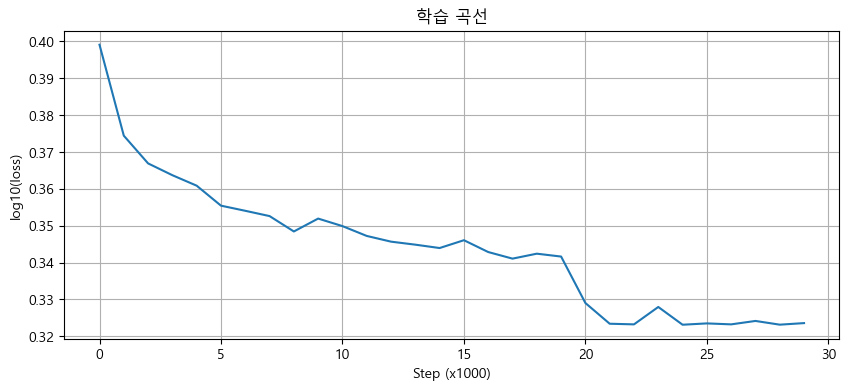

In [12]:
# 학습 곡선
plt.figure(figsize=(10, 4))
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.xlabel('Step (x1000)'); plt.ylabel('log10(loss)')
plt.title('학습 곡선')
plt.grid(True)
plt.show()

---
## 📺 01:05:00 - 01:20:00 | 평가

In [13]:
@torch.no_grad()
def eval_loss(X, Y):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print(f'Train loss: {eval_loss(Xtr, Ytr):.4f}')
print(f'Val loss:   {eval_loss(Xdev, Ydev):.4f}')

Train loss: 2.1139
Val loss:   2.1457


---
## 📺 01:20:00 - 01:30:00 | 이름 생성 & 임베딩 시각화

In [14]:
# 이름 생성
g_sample = torch.Generator().manual_seed(2147483647)

for _ in range(15):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cer.
mariah.
makila.
kayderrinishana.
noluwan.
kata.
kreez.
pella.
hamilias.
moriella.
kinzoreda.
kaley.
maside.
eniavirny.
fobspehiline.


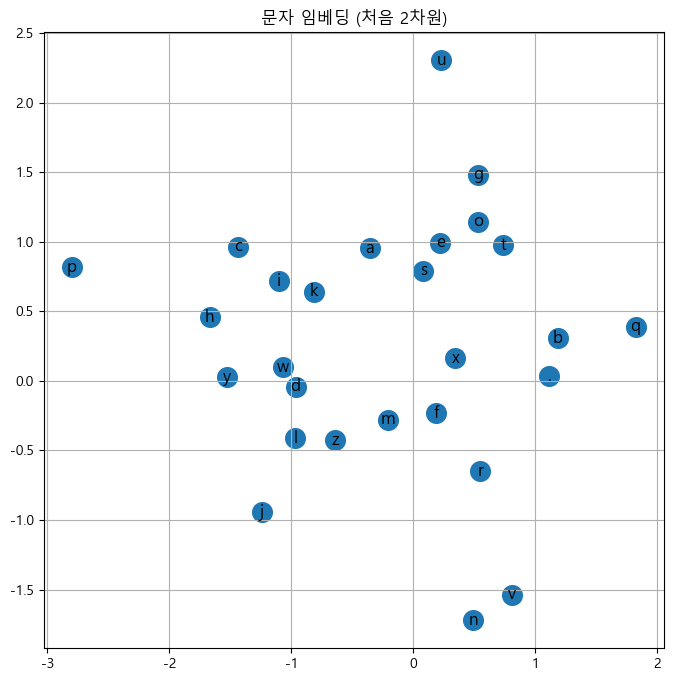

In [15]:
# 임베딩 시각화 (2D일 때만 의미 있음, n_embd>2일 경우 PCA/t-SNE 필요)
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(vocab_size):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', fontsize=12)
plt.title('문자 임베딩 (처음 2차원)')
plt.grid(True)
plt.show()